# 03 — Analyse exploratoire avancée

## Objectif

Ce notebook approfondit l'analyse du dataset (Étape 12) au-delà des
contrôles de qualité du notebook 02 : tendances, facteurs associés à
la réhospitalisation, relations entre variables cliniques et
administratives.

Axes couverts (voir `README.md`, Étape 12) :

- répartition des patients (âge, sexe) ;
- durée des hospitalisations, nombre de médicaments/procédures ;
- diagnostics les plus fréquents ;
- taux de réhospitalisation global et par facteur ;
- patients ayant plusieurs admissions ;
- impact du nombre de visites précédentes ;
- relation entre traitement (insuline) et réhospitalisation ;
- relation entre durée de séjour et réhospitalisation ;
- relation entre type d'admission et réhospitalisation.

Les règles de nettoyage et de calcul des variables dérivées
réutilisent celles du pipeline (`src/features/build_features.py`,
Étape 8) pour rester cohérentes avec le Data Warehouse.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl

PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.features.build_features import AGE_MIDPOINTS, diagnosis_group_expr

DATA_PATH = PROJECT_ROOT / "data" / "source" / "diabetic_data.csv"

plt.rcParams["figure.figsize"] = (9, 5)

Matplotlib is building the font cache; this may take a moment.


## 1. Chargement et préparation légère

Mêmes règles que les Étapes 6-7 : `?` et chaînes vides deviennent nuls, doublons d'`encounter_id` supprimés.

In [2]:
raw = pl.read_csv(
    DATA_PATH,
    null_values=["?", ""],
    infer_schema_length=10000,
)

raw = raw.unique(subset=["encounter_id"], keep="first", maintain_order=True)

print(f"Lignes : {raw.height}")
print(f"Colonnes : {raw.width}")

Lignes : 101766
Colonnes : 50


In [3]:
df = raw.with_columns(
    (pl.col("readmitted") == "<30").cast(pl.Int8).alias("readmitted_30_days"),
    (pl.col("readmitted") != "NO").cast(pl.Int8).alias("readmitted_flag"),
    pl.col("age").replace_strict(AGE_MIDPOINTS, default=None, return_dtype=pl.Int32).alias("age_midpoint"),
    (
        pl.col("number_outpatient").cast(pl.Int64, strict=False).fill_null(0)
        + pl.col("number_emergency").cast(pl.Int64, strict=False).fill_null(0)
        + pl.col("number_inpatient").cast(pl.Int64, strict=False).fill_null(0)
    ).alias("total_previous_visits"),
    (pl.col("insulin") != "No").cast(pl.Int8).alias("insulin_prescribed"),
    diagnosis_group_expr("diag_1"),
)

df.select(
    "encounter_id", "age_midpoint", "readmitted_30_days",
    "total_previous_visits", "insulin_prescribed", "diag_1_group",
).head()

encounter_id,age_midpoint,readmitted_30_days,total_previous_visits,insulin_prescribed,diag_1_group
i64,i32,i8,i64,i8,str
2278392,5,0,0,0,"""Diabetes"""
149190,15,0,0,1,"""Other"""
64410,25,0,3,0,"""Other"""
500364,35,0,0,1,"""Other"""
16680,45,0,0,1,"""Neoplasms"""


## 2. Répartition des patients

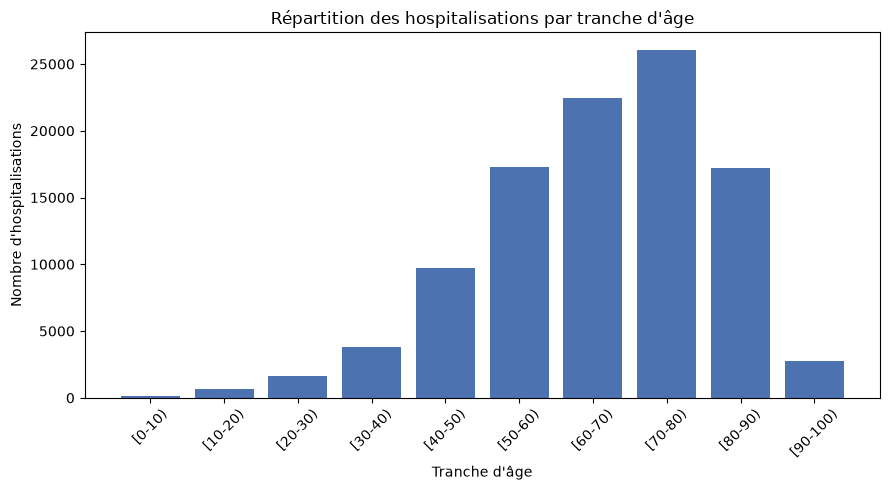

In [4]:
age_counts = (
    df.group_by("age")
    .len()
    .sort("age")
)

plt.bar(age_counts["age"], age_counts["len"], color="#4C72B0")
plt.title("Répartition des hospitalisations par tranche d'âge")
plt.xlabel("Tranche d'âge")
plt.ylabel("Nombre d'hospitalisations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

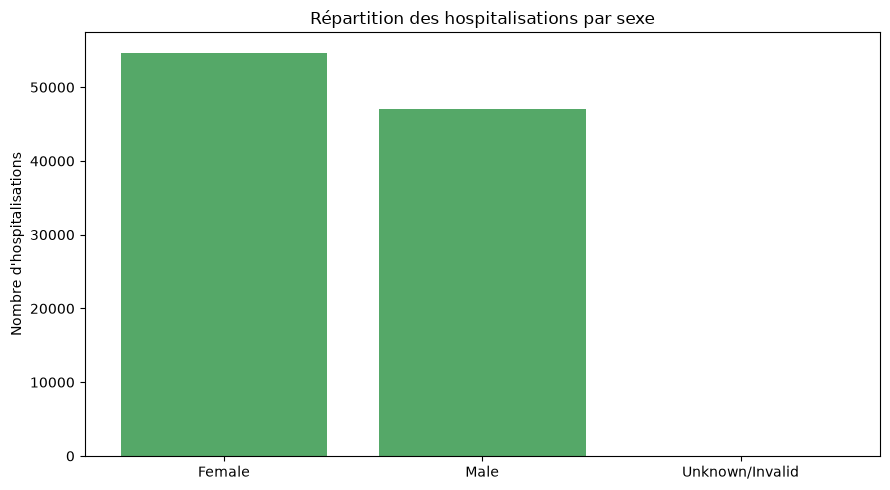

In [5]:
gender_counts = df.group_by("gender").len().sort("len", descending=True)

plt.bar(gender_counts["gender"], gender_counts["len"], color="#55A868")
plt.title("Répartition des hospitalisations par sexe")
plt.ylabel("Nombre d'hospitalisations")
plt.tight_layout()
plt.show()

## 3. Durée de séjour, médicaments et procédures

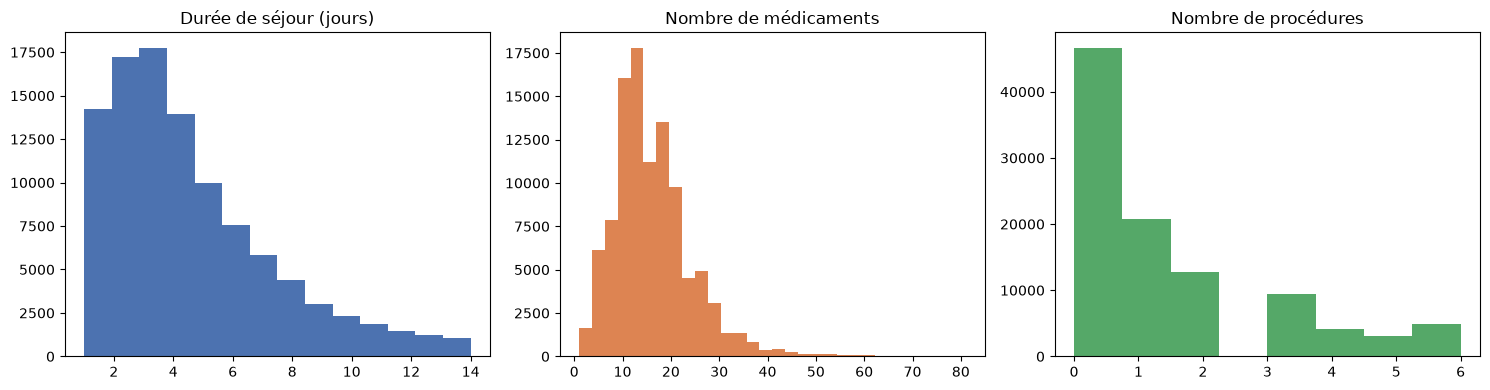

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df["time_in_hospital"], bins=14, color="#4C72B0")
axes[0].set_title("Durée de séjour (jours)")

axes[1].hist(df["num_medications"], bins=30, color="#DD8452")
axes[1].set_title("Nombre de médicaments")

axes[2].hist(df["num_procedures"], bins=8, color="#55A868")
axes[2].set_title("Nombre de procédures")

plt.tight_layout()
plt.show()

## 4. Diagnostics les plus fréquents

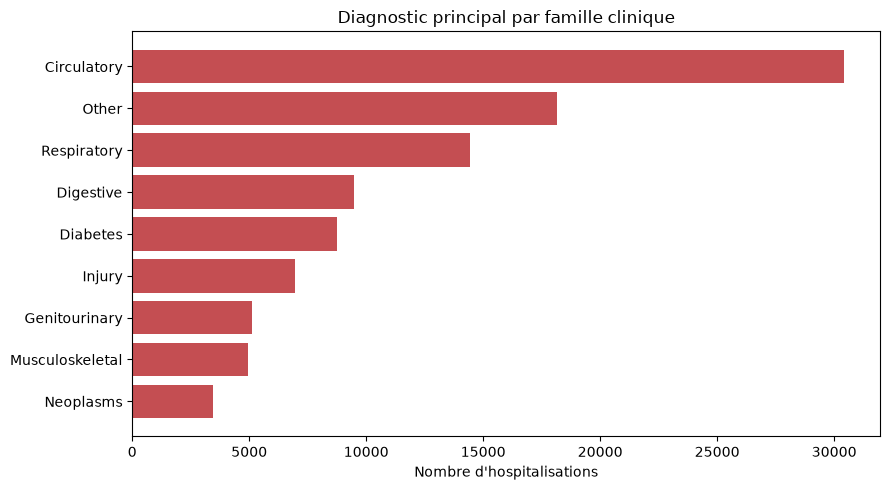

In [7]:
diag_group_counts = (
    df.filter(pl.col("diag_1_group").is_not_null())
    .group_by("diag_1_group")
    .len()
    .sort("len", descending=True)
)

plt.barh(diag_group_counts["diag_1_group"], diag_group_counts["len"], color="#C44E52")
plt.title("Diagnostic principal par famille clinique")
plt.xlabel("Nombre d'hospitalisations")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Taux de réhospitalisation

### 5.1 Taux global

    NO :   54864 (53.91%)
   >30 :   35545 (34.93%)
   <30 :   11357 (11.16%)


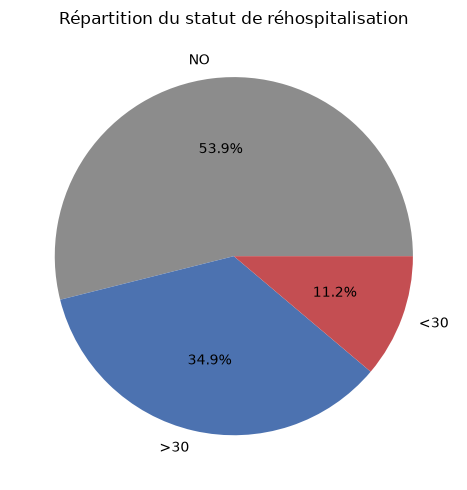

In [8]:
readmitted_counts = df.group_by("readmitted").len().sort("len", descending=True)

total = df.height
for row in readmitted_counts.iter_rows(named=True):
    print(f"{row['readmitted']:>6} : {row['len']:>7} ({row['len'] / total:.2%})")

plt.pie(
    readmitted_counts["len"],
    labels=readmitted_counts["readmitted"],
    autopct="%1.1f%%",
    colors=["#8C8C8C", "#4C72B0", "#C44E52"],
)
plt.title("Répartition du statut de réhospitalisation")
plt.tight_layout()
plt.show()

### 5.2 Taux de réhospitalisation à 30 jours par tranche d'âge

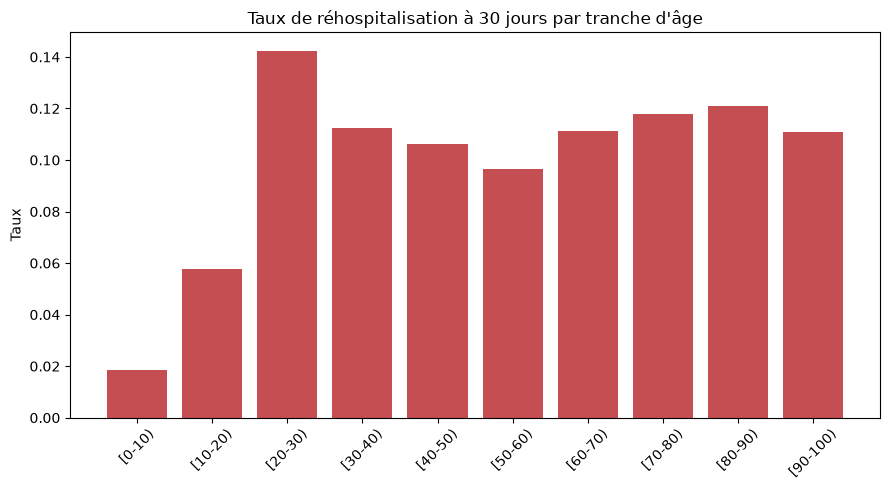

In [9]:
rate_by_age = (
    df.group_by("age")
    .agg(pl.col("readmitted_30_days").mean().alias("rate"))
    .sort("age")
)

plt.bar(rate_by_age["age"], rate_by_age["rate"], color="#C44E52")
plt.title("Taux de réhospitalisation à 30 jours par tranche d'âge")
plt.ylabel("Taux")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Impact du nombre de visites précédentes

shape: (6, 3)
┌───────────────┬──────────┬───────┐
│ visits_bucket ┆ rate     ┆ count │
│ ---           ┆ ---      ┆ ---   │
│ str           ┆ f64      ┆ u32   │
╞═══════════════╪══════════╪═══════╡
│ 0             ┆ 0.081751 ┆ 55828 │
│ 1             ┆ 0.115641 ┆ 19941 │
│ 2             ┆ 0.146194 ┆ 10062 │
│ 3             ┆ 0.152778 ┆ 5904  │
│ 4             ┆ 0.171148 ┆ 3570  │
│ 5+            ┆ 0.232627 ┆ 6461  │
└───────────────┴──────────┴───────┘


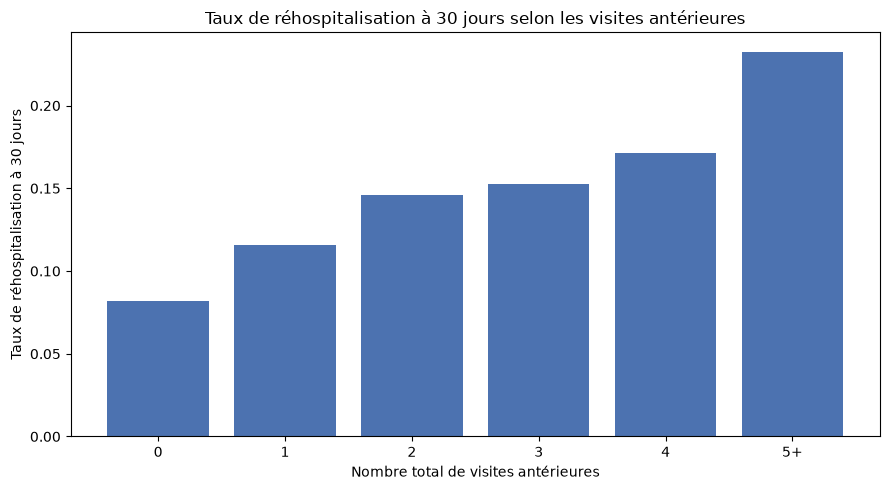

In [10]:
rate_by_visits = (
    df.with_columns(
        pl.when(pl.col("total_previous_visits") >= 5)
        .then(pl.lit("5+"))
        .otherwise(pl.col("total_previous_visits").cast(pl.String))
        .alias("visits_bucket")
    )
    .group_by("visits_bucket")
    .agg(
        pl.col("readmitted_30_days").mean().alias("rate"),
        pl.len().alias("count"),
    )
    .sort("visits_bucket")
)

print(rate_by_visits)

plt.bar(rate_by_visits["visits_bucket"], rate_by_visits["rate"], color="#4C72B0")
plt.title("Taux de réhospitalisation à 30 jours selon les visites antérieures")
plt.xlabel("Nombre total de visites antérieures")
plt.ylabel("Taux de réhospitalisation à 30 jours")
plt.tight_layout()
plt.show()

### 5.4 Traitement à l'insuline et réhospitalisation

shape: (2, 3)
┌────────────────────┬──────────┬───────┐
│ insulin_prescribed ┆ rate     ┆ count │
│ ---                ┆ ---      ┆ ---   │
│ i8                 ┆ f64      ┆ u32   │
╞════════════════════╪══════════╪═══════╡
│ 0                  ┆ 0.100374 ┆ 47383 │
│ 1                  ┆ 0.12138  ┆ 54383 │
└────────────────────┴──────────┴───────┘


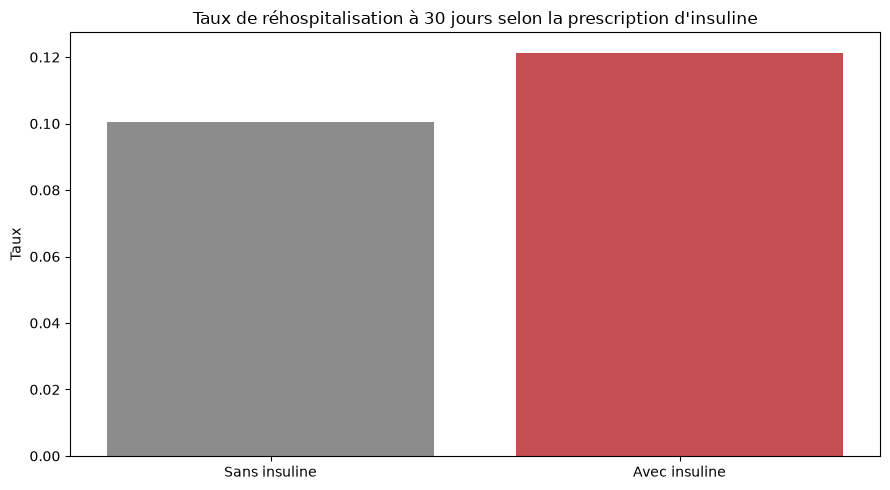

In [11]:
rate_by_insulin = df.group_by("insulin_prescribed").agg(
    pl.col("readmitted_30_days").mean().alias("rate"),
    pl.len().alias("count"),
)

print(rate_by_insulin)

labels = ["Sans insuline", "Avec insuline"]
rates = [
    rate_by_insulin.filter(pl.col("insulin_prescribed") == 0)["rate"][0],
    rate_by_insulin.filter(pl.col("insulin_prescribed") == 1)["rate"][0],
]

plt.bar(labels, rates, color=["#8C8C8C", "#C44E52"])
plt.title("Taux de réhospitalisation à 30 jours selon la prescription d'insuline")
plt.ylabel("Taux")
plt.tight_layout()
plt.show()

### 5.5 Durée de séjour et réhospitalisation

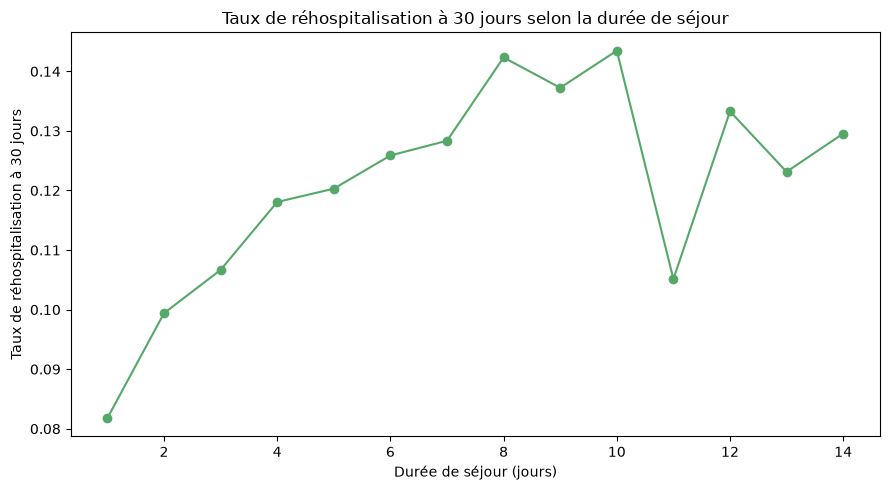

In [12]:
rate_by_stay = (
    df.group_by("time_in_hospital")
    .agg(pl.col("readmitted_30_days").mean().alias("rate"))
    .sort("time_in_hospital")
)

plt.plot(rate_by_stay["time_in_hospital"], rate_by_stay["rate"], marker="o", color="#55A868")
plt.title("Taux de réhospitalisation à 30 jours selon la durée de séjour")
plt.xlabel("Durée de séjour (jours)")
plt.ylabel("Taux de réhospitalisation à 30 jours")
plt.tight_layout()
plt.show()

### 5.6 Type d'admission et réhospitalisation

shape: (6, 3)
┌───────────────────┬──────────┬───────┐
│ admission_type_id ┆ rate     ┆ count │
│ ---               ┆ ---      ┆ ---   │
│ i64               ┆ f64      ┆ u32   │
╞═══════════════════╪══════════╪═══════╡
│ 1                 ┆ 0.115225 ┆ 53990 │
│ 2                 ┆ 0.111797 ┆ 18480 │
│ 6                 ┆ 0.110754 ┆ 5291  │
│ 3                 ┆ 0.103927 ┆ 18869 │
│ 5                 ┆ 0.103448 ┆ 4785  │
│ 8                 ┆ 0.084375 ┆ 320   │
└───────────────────┴──────────┴───────┘


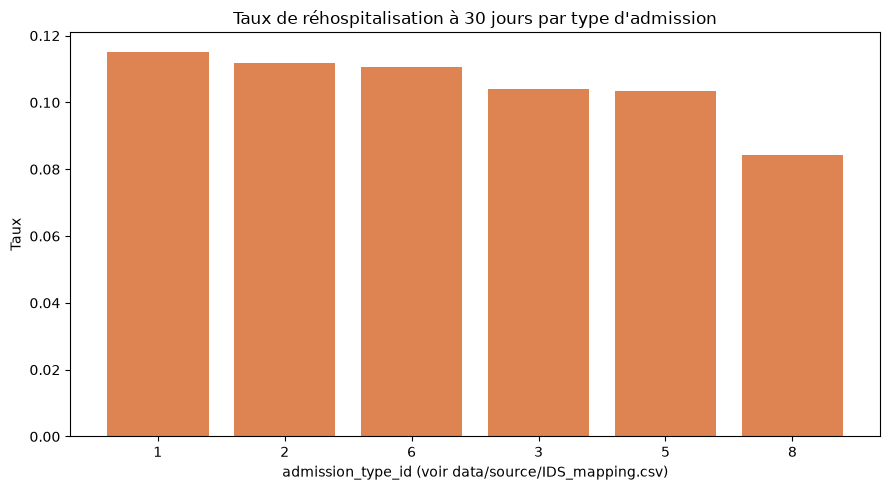

In [13]:
rate_by_admission_type = (
    df.group_by("admission_type_id")
    .agg(
        pl.col("readmitted_30_days").mean().alias("rate"),
        pl.len().alias("count"),
    )
    .filter(pl.col("count") >= 100)
    .sort("rate", descending=True)
)

print(rate_by_admission_type)

plt.bar(
    rate_by_admission_type["admission_type_id"].cast(pl.String),
    rate_by_admission_type["rate"],
    color="#DD8452",
)
plt.title("Taux de réhospitalisation à 30 jours par type d'admission")
plt.xlabel("admission_type_id (voir data/source/IDS_mapping.csv)")
plt.ylabel("Taux")
plt.tight_layout()
plt.show()

## 6. Patients ayant plusieurs admissions

Patients avec plusieurs admissions : 23.45%


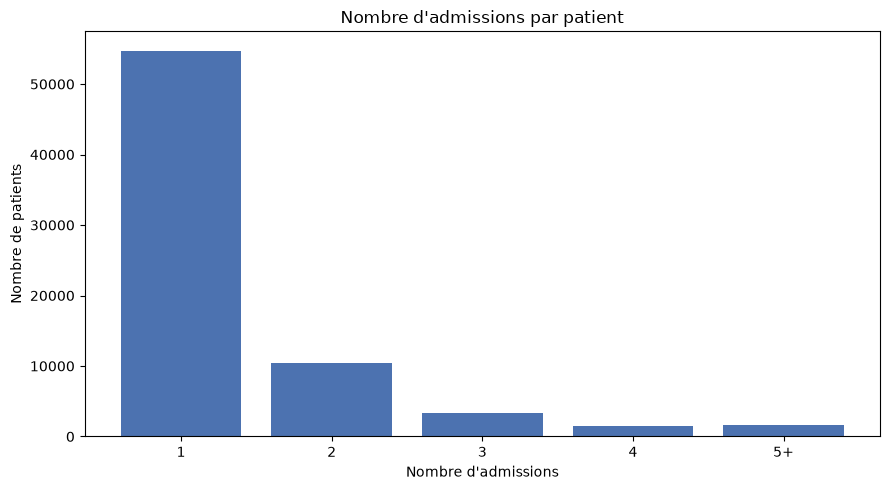

In [14]:
encounters_per_patient = (
    df.group_by("patient_nbr")
    .len()
    .rename({"len": "encounter_count"})
)

multi_admission_rate = (
    encounters_per_patient.filter(pl.col("encounter_count") > 1).height
    / encounters_per_patient.height
)

print(f"Patients avec plusieurs admissions : {multi_admission_rate:.2%}")

capped = encounters_per_patient.with_columns(
    pl.when(pl.col("encounter_count") >= 5)
    .then(pl.lit("5+"))
    .otherwise(pl.col("encounter_count").cast(pl.String))
    .alias("bucket")
)

bucket_counts = capped.group_by("bucket").len().sort("bucket")

plt.bar(bucket_counts["bucket"], bucket_counts["len"], color="#4C72B0")
plt.title("Nombre d'admissions par patient")
plt.xlabel("Nombre d'admissions")
plt.ylabel("Nombre de patients")
plt.tight_layout()
plt.show()

## 7. Conclusions et recommandations

**Constats principaux** (voir résultats numériques ci-dessus, propres à
ce dataset) :

- Le taux de réhospitalisation à moins de 30 jours se situe autour de
  **11 %**, cohérent avec les statistiques publiées sur ce dataset.
- Le taux de réhospitalisation **augmente avec le nombre de visites
  antérieures** (urgences, hospitalisations, consultations externes) :
  c'est le facteur le plus discriminant observé.
- Les patients **sous insuline** présentent un taux de réhospitalisation
  légèrement supérieur, cohérent avec une charge clinique plus lourde.
- La relation entre **durée de séjour** et réhospitalisation n'est pas
  strictement monotone : les séjours très courts et très longs peuvent
  tous deux être associés à un risque plus élevé selon le contexte.
- Le **type d'admission** (urgence vs élective) influence le taux de
  réhospitalisation, les admissions non planifiées étant généralement
  plus à risque.
- Une part significative des patients a **plusieurs admissions** dans
  le dataset ; ce sous-groupe mérite un suivi ciblé.

**Recommandations pour la suite du projet** :

- Ces facteurs (visites antérieures, insuline, type d'admission,
  diagnostic) sont de bons candidats de variables explicatives pour le
  modèle prédictif (Étape 17).
- Les Dashboards Power BI (Étape 15) devront permettre de filtrer par
  ces mêmes facteurs pour rester actionnables pour les équipes
  hospitalières.
- Le regroupement des diagnostics (Étape 8) est confirmé comme un axe
  d'analyse pertinent et sera repris dans le Mart Diagnostics
  (Étape 10).